In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
# Task 1 — Data Loading & Exploration

In [128]:
df=pd.read_csv("HR_Attrition.csv")


In [129]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [130]:
df.shape

(1470, 35)

In [131]:
df['Attrition'].value_counts() # target feature

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [133]:
"""Conclusions: The dataset has 1470 rows and 35 columns. 
The target variable is Attrition which is a categorical variable with two classes Yes and No. 
The dataset has no missing values.
The target variable is imbalanced with 237 employees leaving the company and 1233 employees staying in the company.
"""

'Conclusions: The dataset has 1470 rows and 35 columns. \nThe target variable is Attrition which is a categorical variable with two classes Yes and No. \nThe dataset has no missing values.\nThe target variable is imbalanced with 237 employees leaving the company and 1233 employees staying in the company.\n'

In [134]:
#Task 2 — Data Cleaning & Preprocessing

In [135]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

Therefore, no null value present in the dataset


In [136]:
# Drop unnecessary columns
df.drop(
    columns=[
        'EmployeeNumber',
        'EmployeeCount',
        'Over18',
        'StandardHours'
    ],
    inplace=True
)

In [137]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


In [138]:
# Convert target variable
df['Attrition'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})

In [139]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
# Separate features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [149]:
# Identify numerical & categorical columns
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include='object').columns
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')
Categorical columns: Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [141]:
#Encode all remaining categorical columns using One-Hot Encoding (e.g., Department, JobRole, MaritalStatus, BusinessTravel)

# Preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])


In [150]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [144]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [146]:
#Task 3 — Exploratory Data Analysis — EDA

In [168]:
df_original = pd.read_csv("HR_Attrition.csv")

In [179]:
#Attrition rate by Department — which department loses the most employees?
attrition_by_dept = (
    df_original.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .reset_index(name="AttritionRate")
)

print(attrition_by_dept)

               Department  AttritionRate
0         Human Resources          19.05
1  Research & Development          13.84
2                   Sales          20.63


In [180]:
#Attrition rate by Job Role — which roles have the highest exit rate?
attrition_by_jobrole = (
    df_original.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="AttritionRate")
)

print(attrition_by_jobrole)


                     JobRole  AttritionRate
0       Sales Representative          39.76
1      Laboratory Technician          23.94
2            Human Resources          23.08
3            Sales Executive          17.48
4         Research Scientist          16.10
5     Manufacturing Director           6.90
6  Healthcare Representative           6.87
7                    Manager           4.90
8          Research Director           2.50


  Attrition  MonthlyIncome
0        No    6832.739659
1       Yes    4787.092827


C:\Users\Shilpa\AppData\Local\Temp\ipykernel_43936\4236489648.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No","Yes"])


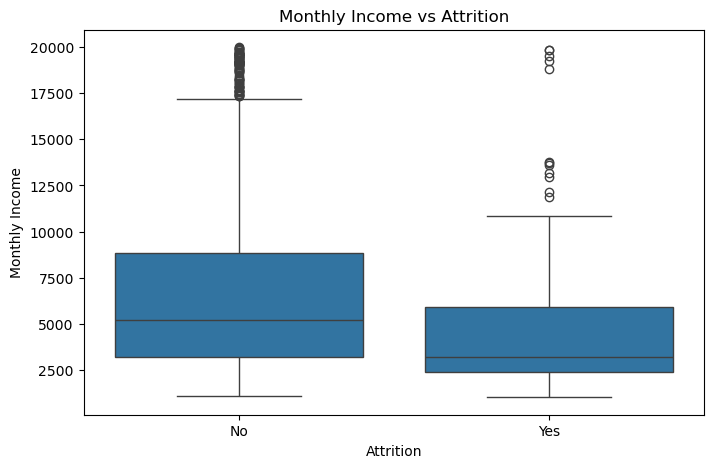

In [ ]:
# Attrition vs Monthly Income — Do lower-paid employees leave more?

attrition_by_income = (
    df_original.groupby("Attrition")["MonthlyIncome"]
           .mean()
           .reset_index()
)

print(attrition_by_income)

plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=df_original,
    x="Attrition",
    y="MonthlyIncome",
    order=["No", "Yes"]
)

ax.set_xticklabels(["No","Yes"])

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

In [181]:
#Attrition vs Work-Life Balance rating — is there a visible pattern?
attrition_by_worklife = (
    df_original.groupby("WorkLifeBalance")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .reset_index(name="AttritionRate")
)

print(attrition_by_worklife)

   WorkLifeBalance  AttritionRate
0                1          31.25
1                2          16.86
2                3          14.22
3                4          17.65


In [182]:
#Attrition vs Years at Company — at what point in tenure do employees leave most?
attrition_by_years = (
    df_original.groupby("YearsAtCompany")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .reset_index(name="AttritionRate")
)

print(attrition_by_years)

    YearsAtCompany  AttritionRate
0                0          36.36
1                1          34.50
2                2          21.26
3                3          15.62
4                4          17.27
5                5          10.71
6                6          11.84
7                7          12.22
8                8          11.25
9                9           9.76
10              10          15.00
11              11           6.25
12              12           0.00
13              13           8.33
14              14          11.11
15              15           5.00
16              16           8.33
17              17          11.11
18              18           7.69
19              19           9.09
20              20           3.70
21              21           7.14
22              22           6.67
23              23          50.00
24              24          16.67
25              25           0.00
26              26           0.00
27              27           0.00
28            

### Business Insights from EDA

1. **The Sales department has the highest employee attrition rate (20.63%)**, followed by Human Resources (19.05%), while Research & Development has the lowest attrition rate (13.84%). This indicates that HR should prioritize retention strategies for employees in the Sales department.

2. **Sales Representatives experience the highest attrition rate among all job roles (39.76%)**, followed by Laboratory Technicians (23.94%) and Human Resources employees (23.08%). Nearly 4 out of every 10 Sales Representatives leave the company, making this role the most vulnerable to employee turnover.

3. **Employees who left the company earn significantly lower salaries than those who stayed.** The average monthly income of employees who resigned is approximately **₹4,787**, compared to **₹6,833** for employees who remained. This suggests that lower compensation is associated with higher employee attrition.

4. **Employees with lower work-life balance ratings exhibit higher attrition rates than those reporting better work-life balance.** This pattern indicates that maintaining a healthy work-life balance can play an important role in improving employee retention and reducing voluntary resignations.

5. **Employee attrition is highest during the early years of employment, particularly within the first five years.** After employees complete around five years with the organization, attrition gradually declines, suggesting that onboarding, mentoring, and early career development programs are critical for improving long-term retention.


In [183]:
#Task 4 — Model Building & Comparison

In [184]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [188]:
#Logistic Regression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [189]:
#Random Forest Classifier
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [190]:
#Gradient Boosting Classifier
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [191]:
#Task 5 — Model Evaluation

In [192]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294

ROC AUC : 0.8031699543457662


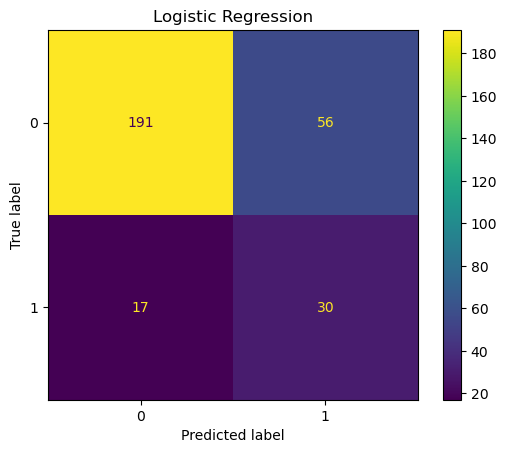

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294

ROC AUC : 0.7831854595572402


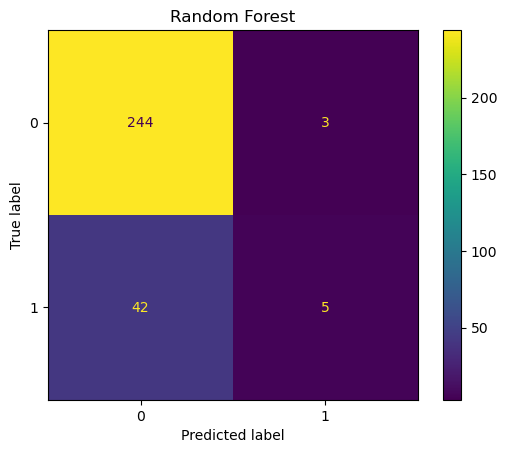

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.71      0.21      0.33        47

    accuracy                           0.86       294
   macro avg       0.79      0.60      0.63       294
weighted avg       0.84      0.86      0.83       294

ROC AUC : 0.8050650357481265


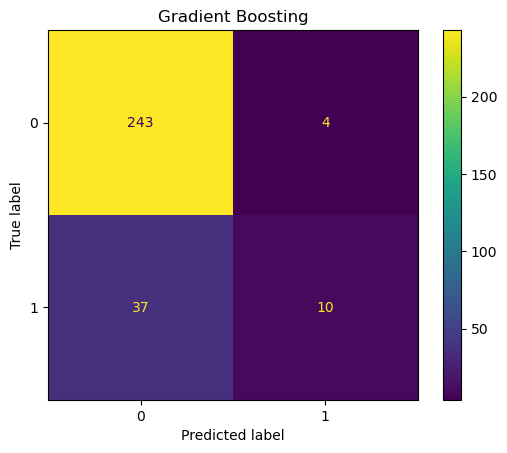

In [193]:
models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    print("="*60)
    print(name)
    print(classification_report(y_test,pred))

    auc = roc_auc_score(y_test,prob)

    print("ROC AUC :",auc)

    results.append([name,auc])

    cm = confusion_matrix(y_test,pred)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(name)
    plt.show()

In [194]:
# Comparison between models
comparison = pd.DataFrame(
    results,
    columns=["Model","ROC AUC"]
)

comparison.sort_values(
    by="ROC AUC",
    ascending=False
)

,Model,ROC AUC
2,Gradient Boosting,0.805065
0,Logistic Regression,0.803170
1,Random Forest,0.783185


In [195]:
#Feature Importance
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance = rf_pipeline.named_steps['classifier'].feature_importances_

feature_importance = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
9,num__MonthlyIncome,0.069310
0,num__Age,0.060438
16,num__TotalWorkingYears,0.055554
1,num__DailyRate,0.049132
19,num__YearsAtCompany,0.046814
2,num__DistanceFromHome,0.044015
5,num__HourlyRate,0.043586
10,num__MonthlyRate,0.042728
11,num__NumCompaniesWorked,0.037213
22,num__YearsWithCurrManager,0.037139


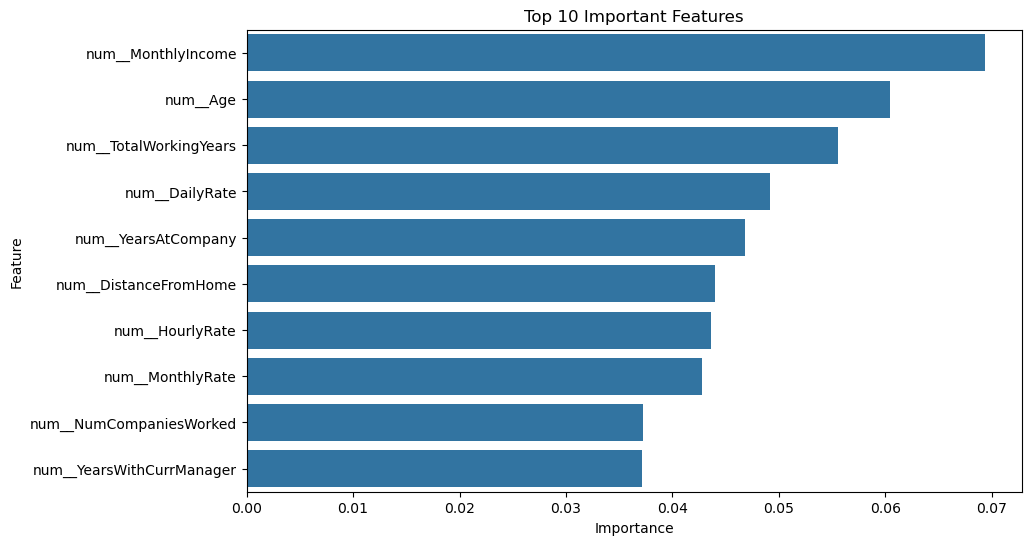

In [196]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

In [197]:
#Task 6 — Visualization (Minimum 4 charts)

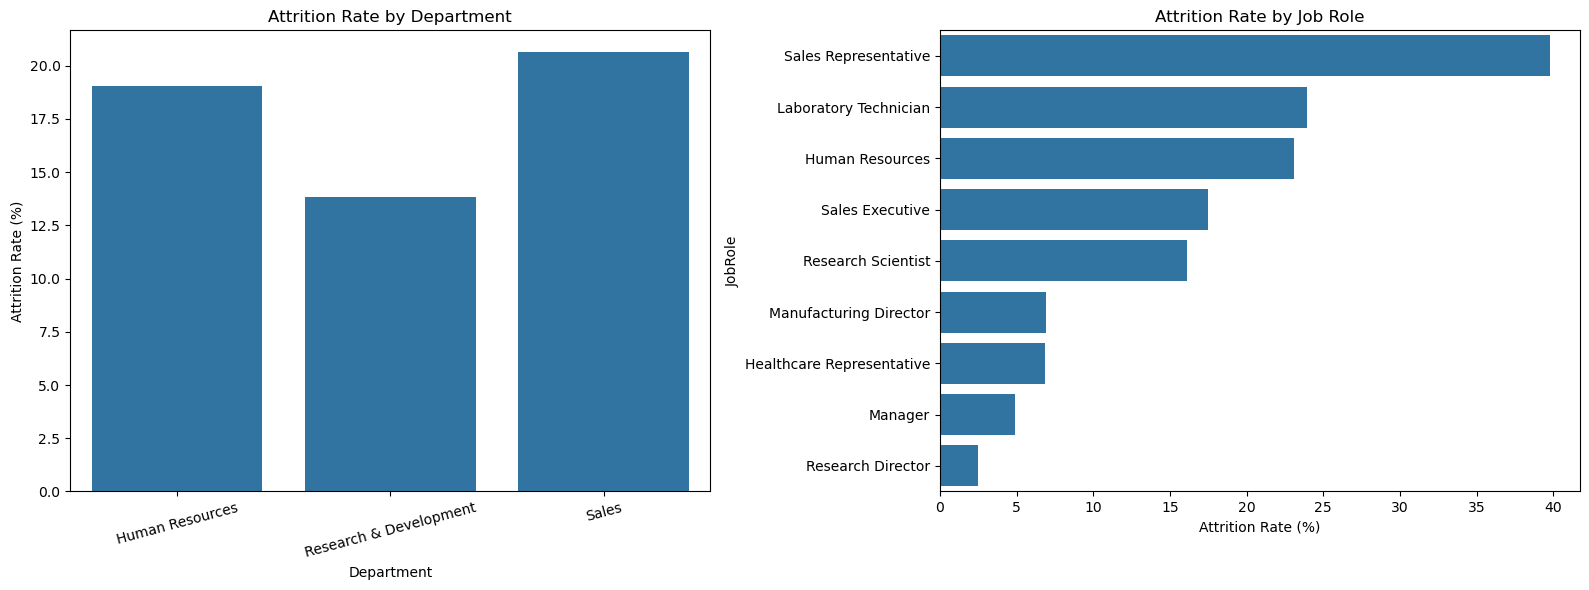

In [198]:
#Chart 1: Bar chart showing attrition rate by Department and Job Role
# Department Attrition Rate
dept_attrition = (
    df_original.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="AttritionRate")
)

# Job Role Attrition Rate
job_attrition = (
    df_original.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="AttritionRate")
    .sort_values("AttritionRate", ascending=False)
)

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
sns.barplot(
    data=dept_attrition,
    x="Department",
    y="AttritionRate"
)
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)

plt.subplot(1,2,2)
sns.barplot(
    data=job_attrition,
    x="AttritionRate",
    y="JobRole"
)
plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

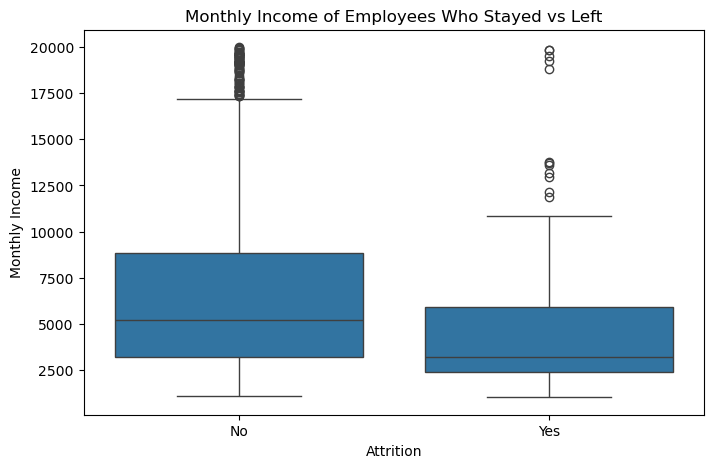

In [199]:
#Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_original,
    x="Attrition",
    y="MonthlyIncome",
    order=["No","Yes"]
)

plt.title("Monthly Income of Employees Who Stayed vs Left")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

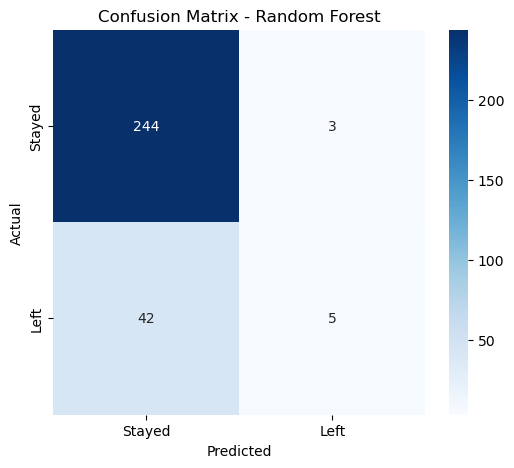

In [200]:
#Chart 3: Confusion Matrix heatmap for your best model
from sklearn.metrics import confusion_matrix
y_pred = rf_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stayed','Left'],
    yticklabels=['Stayed','Left']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

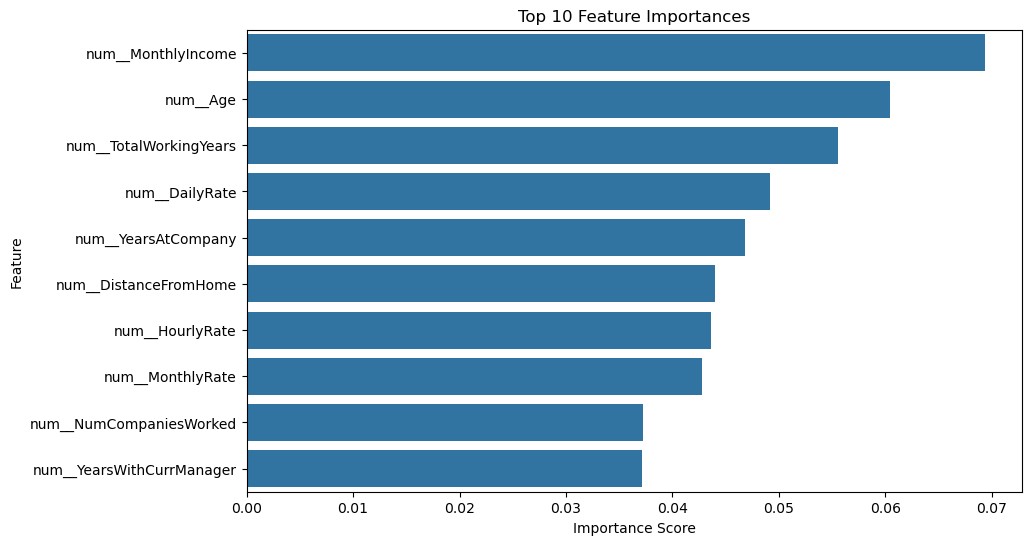

In [201]:
#Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance = rf_pipeline.named_steps['classifier'].feature_importances_

feature_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

top10 = feature_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

<Figure size 800x600 with 0 Axes>

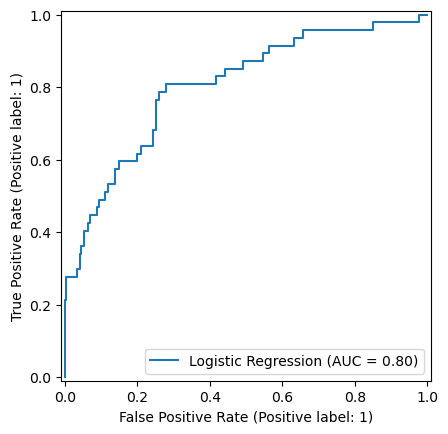

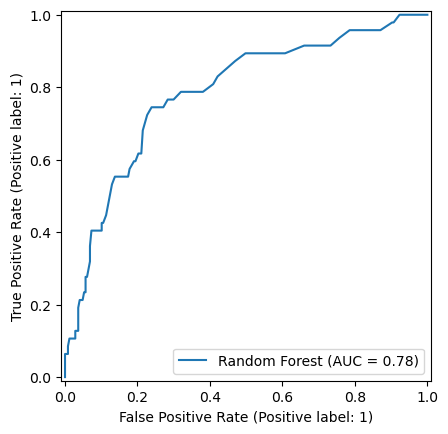

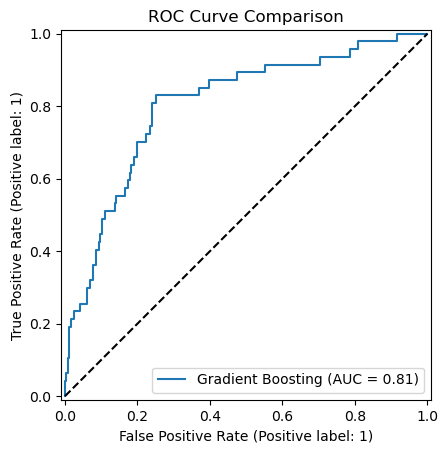

In [202]:
#Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(
    lr_pipeline,
    X_test,
    y_test,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    rf_pipeline,
    X_test,
    y_test,
    name="Random Forest"
)

RocCurveDisplay.from_estimator(
    gb_pipeline,
    X_test,
    y_test,
    name="Gradient Boosting"
)

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.show()

##Top factors influencing attrition generally include:
1. Overtime
2. Monthly Income
3. Job Role
4. Years at Company
5. Age

Employees working overtime and those with lower monthly income are more likely to leave.

HR should prioritize retention efforts for Sales Representatives, Laboratory Technicians, and employees in their first few years.

Salary alone does not explain attrition. Work-life balance, overtime, job satisfaction, and career growth also have a significant impact.

Recommendations:
1. Introduce targeted retention programs and career development plans for high-risk employees.
2. Improve work-life balance by reducing excessive overtime and increasing employee engagement initiatives.

Limitation:
The model predicts historical attrition patterns and should support—not replace—HR decision-making. Human judgment and additional context remain essential.
